# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [30]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from myutil import evaluate_skewness

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [31]:
# Load and view a smaple of the data
survey = pd.read_csv('./data.csv')
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


In [32]:
survey.shape

(4184, 55)

---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [33]:
# Filter your data to include Q1 to Q44 and hand

# Generate column names from Q1 to Q44
q_columns = [f'Q{i}' for i in range(1, 45)]

# Combine with 'hand' and filter your dataframe
# Make sure to replace 'survey' with your actual dataframe name if it's different
selected_columns = q_columns + ['hand']
survey_filtered = survey[selected_columns]

survey_filtered.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
0,4,1,5,1,5,1,5,1,4,1,...,1,1,1,5,5,5,1,5,1,3
1,1,5,1,4,2,5,5,4,1,5,...,4,4,4,1,3,1,4,4,5,1
2,1,2,1,1,5,4,3,2,1,4,...,2,4,2,1,4,2,2,2,2,2
3,1,4,1,5,1,4,5,4,3,5,...,1,3,4,1,2,1,1,1,3,2
4,5,1,5,1,5,1,5,1,3,1,...,1,1,1,5,5,5,1,5,1,3


### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [34]:
# Check Data Information
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 55 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Q1           4184 non-null   int64
 1   Q2           4184 non-null   int64
 2   Q3           4184 non-null   int64
 3   Q4           4184 non-null   int64
 4   Q5           4184 non-null   int64
 5   Q6           4184 non-null   int64
 6   Q7           4184 non-null   int64
 7   Q8           4184 non-null   int64
 8   Q9           4184 non-null   int64
 9   Q10          4184 non-null   int64
 10  Q11          4184 non-null   int64
 11  Q12          4184 non-null   int64
 12  Q13          4184 non-null   int64
 13  Q14          4184 non-null   int64
 14  Q15          4184 non-null   int64
 15  Q16          4184 non-null   int64
 16  Q17          4184 non-null   int64
 17  Q18          4184 non-null   int64
 18  Q19          4184 non-null   int64
 19  Q20          4184 non-null   int64
 20  Q21          4184 n

In [35]:
# Summary Stat.
survey.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,introelapse,testelapse,fromgoogle,engnat,age,education,gender,race,religion,hand
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,...,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,1.962715,3.829589,2.846558,3.186902,2.865440,3.672084,3.216539,3.184512,2.761233,3.522945,...,347.808556,479.994503,1.576243,1.239962,30.370698,2.317878,1.654398,5.013623,2.394359,1.190966
std,1.360291,1.551683,1.664804,1.476879,1.545798,1.342238,1.490733,1.387382,1.511805,1.242890,...,5908.901681,3142.178542,0.494212,0.440882,367.201726,0.874264,0.640915,1.970996,2.184164,0.495357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,7.000000,1.000000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,3.000000,...,6.000000,186.000000,1.000000,1.000000,18.000000,2.000000,1.000000,5.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,...,12.000000,242.000000,2.000000,1.000000,21.000000,2.000000,2.000000,6.000000,2.000000,1.000000
75%,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,35.000000,324.250000,2.000000,1.000000,27.000000,3.000000,2.000000,6.000000,2.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,252063.000000,119834.000000,2.000000,2.000000,23763.000000,4.000000,3.000000,7.000000,7.000000,3.000000


In [36]:
# Check for nulls
survey.isnull().sum()

Q1             0
Q2             0
Q3             0
Q4             0
Q5             0
Q6             0
Q7             0
Q8             0
Q9             0
Q10            0
Q11            0
Q12            0
Q13            0
Q14            0
Q15            0
Q16            0
Q17            0
Q18            0
Q19            0
Q20            0
Q21            0
Q22            0
Q23            0
Q24            0
Q25            0
Q26            0
Q27            0
Q28            0
Q29            0
Q30            0
Q31            0
Q32            0
Q33            0
Q34            0
Q35            0
Q36            0
Q37            0
Q38            0
Q39            0
Q40            0
Q41            0
Q42            0
Q43            0
Q44            0
introelapse    0
testelapse     0
country        0
fromgoogle     0
engnat         0
age            0
education      0
gender         0
race           0
religion       0
hand           0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> The features Q1 to Q44 contain ordinal values (specifically Likert-scale survey responses ranging from 0 or 1 to 5, representing ordered categorical data reflecting participants' levels of agreement or ratings).
> 


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

In [37]:
# Check correlation using 'spearman'

survey_filtered.corr(method='spearman')

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
Q1,1.000000,-0.118039,0.281336,-0.051184,0.209358,-0.067870,0.177012,-0.130499,0.241865,-0.052877,...,-0.068738,0.173360,-0.051918,0.296961,-0.073650,0.161472,-0.050000,0.210551,-0.078729,0.038819
Q2,-0.118039,1.000000,-0.007345,0.267212,-0.049983,0.144341,-0.096585,0.132858,-0.086902,0.140719,...,0.211084,-0.080983,0.233455,-0.035505,0.246509,-0.121881,0.226816,-0.017865,0.290222,-0.019378
Q3,0.281336,-0.007345,1.000000,0.071939,0.278312,-0.014694,0.223326,-0.115027,0.428076,-0.029851,...,-0.007055,0.241841,-0.031986,0.496725,-0.042545,0.218153,0.001283,0.275394,-0.003149,0.040980
Q4,-0.051184,0.267212,0.071939,1.000000,0.060906,0.074410,-0.042319,0.143752,-0.066036,0.051144,...,0.240342,-0.074810,0.376024,0.028491,0.223322,-0.026561,0.329851,0.014976,0.339992,0.011445
Q5,0.209358,-0.049983,0.278312,0.060906,1.000000,0.080643,0.252083,-0.045991,0.232806,0.008229,...,-0.018837,0.173966,0.031545,0.250027,-0.010353,0.205186,0.018918,0.263878,0.012083,0.034693
Q6,-0.067870,0.144341,-0.014694,0.074410,0.080643,1.000000,0.023930,0.088452,-0.029934,0.195167,...,0.008849,0.087662,0.041473,-0.010416,-0.015350,0.031272,0.115456,0.032794,0.109505,-0.014195
Q7,0.177012,-0.096585,0.223326,-0.042319,0.252083,0.023930,1.000000,-0.067351,0.255081,-0.022741,...,-0.085344,0.174003,-0.068336,0.206541,-0.085669,0.169673,-0.053980,0.188347,-0.065370,0.030956
Q8,-0.130499,0.132858,-0.115027,0.143752,-0.045991,0.088452,-0.067351,1.000000,-0.087505,0.033157,...,0.201087,-0.109051,0.236575,-0.144709,0.179640,-0.102912,0.156070,-0.125147,0.163933,-0.030309
Q9,0.241865,-0.086902,0.428076,-0.066036,0.232806,-0.029934,0.255081,-0.087505,1.000000,0.003859,...,-0.059759,0.266650,-0.122573,0.357504,-0.107155,0.187735,-0.072271,0.257732,-0.082525,0.011307
Q10,-0.052877,0.140719,-0.029851,0.051144,0.008229,0.195167,-0.022741,0.033157,0.003859,1.000000,...,0.033136,0.080323,0.046296,-0.022915,0.043763,-0.035516,0.126273,0.024406,0.091335,-0.018156


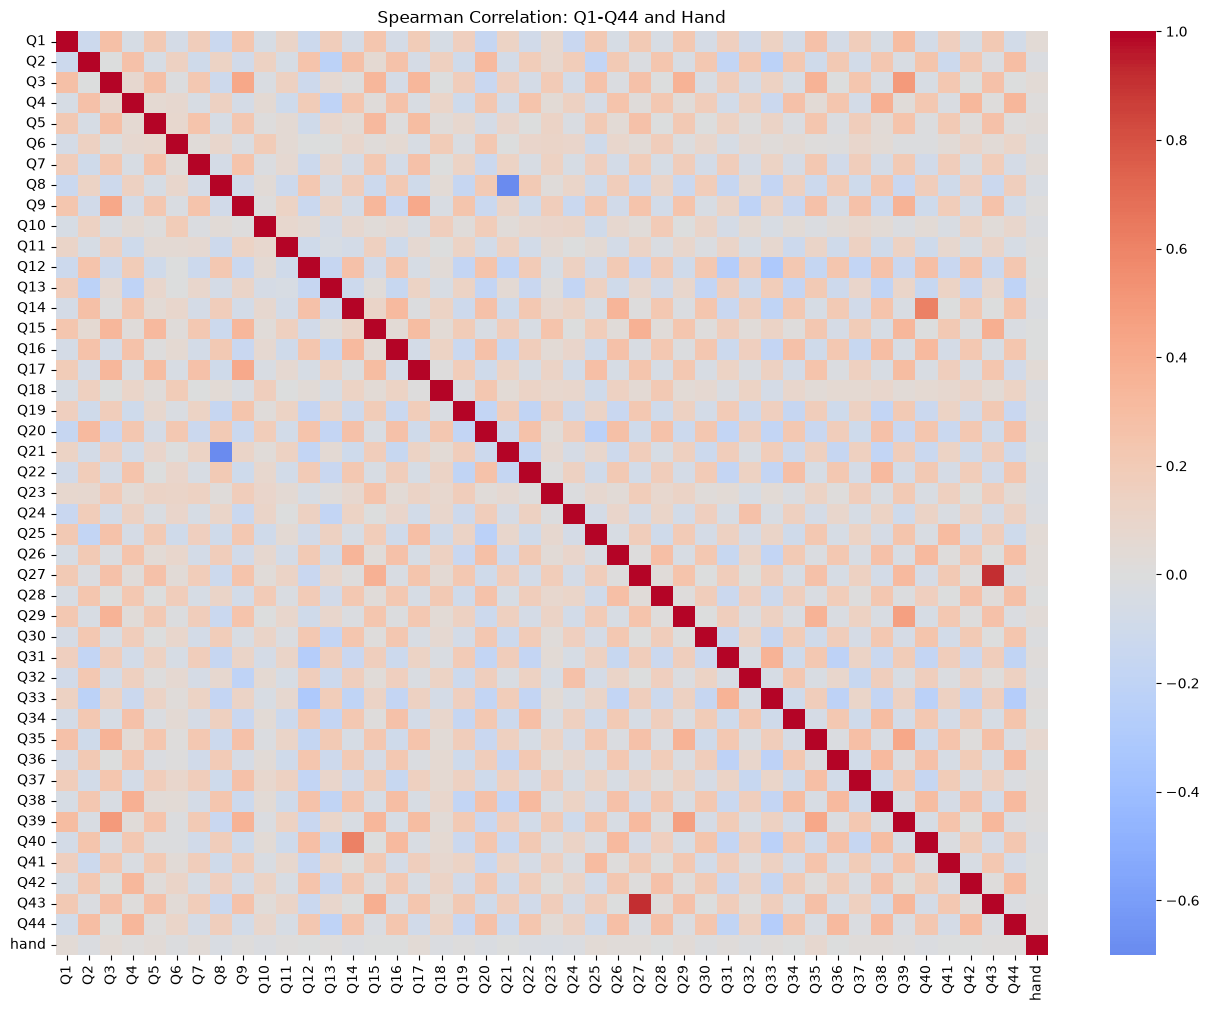

Q35    0.072926
Q3     0.040980
Q17    0.040889
Q25    0.040065
Q1     0.038819
Q5     0.034693
Q23   -0.032213
Q29    0.031818
Q7     0.030956
Q8    -0.030309
Name: hand, dtype: float64


In [38]:
# Check correlation using 'spearman'
spearman_corr = survey[q_columns + ["hand"]].corr(method="spearman")

plt.figure(figsize=(16, 12))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
plt.title("Spearman Correlation: Q1-Q44 and Hand")
plt.show()

# Correlation of each question with the raw 'hand' column, sorted
hand_corr = spearman_corr["hand"].drop("hand").sort_values(key=abs, ascending=False)
print(hand_corr.head(10))

__Inspect the Target__

**Quick Question:** What does each number in the target column represent?
> Each number in the target column (`hand`) represents the participant's self-reported handedness category (e.g., 1 for right-handed, 2 for left-handed, 3 for both/mixed).

In [39]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?
survey['hand'].value_counts()

hand
1    3542
2     452
3     179
0      11
Name: count, dtype: int64

In [40]:
# What needs to be removed from the Target?
survey = survey[survey['hand'].isin([1, 2, 3])]

In [41]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?

survey['hand'] = survey['hand'].replace({3: 1}) 

survey = survey[survey['hand'].isin([1, 2])]

## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [42]:
# Identify your X and y
X = survey[q_columns]
y = survey["hand"]

In [43]:
# Split the data to train and test for each X and y
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((3338, 44), (835, 44))

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [44]:
# SVM Base Model
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=42))
])
svm_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [45]:
# Random Forest Base Model
rf_base = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])
rf_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
# XGBoost Base Model
xgboost_base = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", xgb.XGBClassifier(random_state=42, eval_metric="logloss"))
])
y_train = y_train - 1
y_test = y_test - 1
xgboost_base.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


__Checking the Base Models performance__

In [47]:
# SVM Base Model Result
print("SVM base model accuracy:", svm_base.score(X_test, y_test))

SVM base model accuracy: 0.10778443113772455


In [48]:
# Random Forest Base Model Result
print("Random Forest base model accuracy:", rf_base.score(X_test, y_test))

Random Forest base model accuracy: 0.10778443113772455


In [49]:
# XGBoost Model Result
print("XGBoost base model accuracy:", xgboost_base.score(X_test, y_test))

XGBoost base model accuracy: 0.8898203592814371


__Comparing the base model performance__

In [51]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """

    # Generate predictions
    y_pred = model.predict(X_test)

    # Display the Classification Report
    print("======================================================")
    print("                CLASSIFICATION REPORT                 ")
    print("======================================================")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0.0))

    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.00      0.00      0.00       745
Left-Handed (1)       0.11      1.00      0.19        90

       accuracy                           0.11       835
      macro avg       0.05      0.50      0.10       835
   weighted avg       0.01      0.11      0.02       835



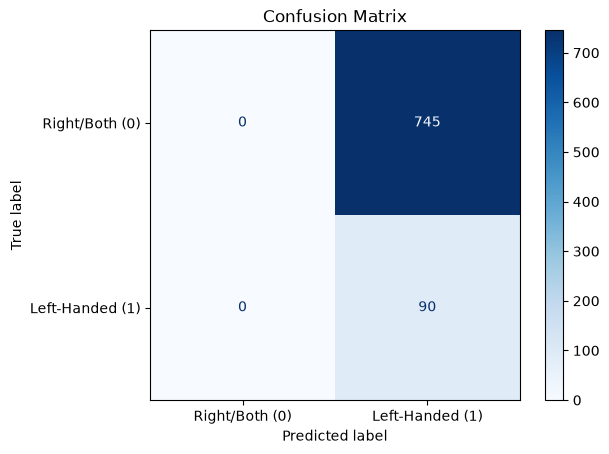

In [52]:
# SVM Base Model Performance
target_classes = ["Right/Both (0)", "Left-Handed (1)"]
evaluate_model_performance(svm_base, X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

In [57]:
# Random Forest Base Model Performance
target_classes = [1,2]
evaluate_model_performance(rf_base, X_test, y_test, target_classes)

SyntaxError: unterminated string literal (detected at line 1) (1372816442.py, line 1)

__3. XGBoost Base Model Performance__

In [ ]:
# XGBoost Base Model Performance
evaluate_model_performance(???)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [ ]:
# SVM Grid Search Parameters
svm_param_grid = 

In [ ]:
# Random Forest Grid Search Parameters
rf_param_grid = 

In [ ]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = 

__Setting up and fitting GridSearch__

In [ ]:
# Setting up and fitting GridSearch for SVM
grid_svm = 

# Fit on training data


# Print best parameters and best cross-validation score
print("Best Parameters:", ???)
print("Best CV F1-Score:", ???)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(???)

In [ ]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = 

# Fit on training data


# Print best parameters and best cross-validation score
print("Best Parameters:", ???)
print("Best CV F1-Score:", ???)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(???)

In [ ]:
# Setting up and fitting GridSearch for XGBoost
xgboost_svm = 

# Fit on training data


# Print best parameters and best cross-validation score
print("Best Parameters:", ???)
print("Best CV F1-Score:", ???)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(???)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here
> ...


### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [ ]:
# Enter you process....


__Preprocessing__

In [ ]:
# Enter you process....


__Modeling__

In [ ]:
# Enter you process....


__Evaluating the Model__

In [ ]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!